# CAMoE — interactive walkthrough

This notebook reproduces the CAMoE results end to end and lets you probe the trained gate at any channel value. Everything runs on CPU in a few seconds.

**The idea:** a Mixture-of-Experts router that sees the wireless **channel quality** and learns to route to a cheap local fallback when the channel is poor, and to remote specialist experts when the channel is good.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from camoe.data import make_clusters, train_test_split
from camoe.model import ChannelAwareMoE
from camoe.train import TrainConfig, train, evaluate_by_channel

torch.manual_seed(0)
np.random.seed(0)

## 1. The task

Four Gaussian clusters, each split into two interleaved sub-classes by an XOR pattern (eight classes total). The XOR makes the task non-linear: a linear model cannot separate the sub-classes, so a cheap linear-ish fallback is genuinely weaker than the nonlinear specialists.

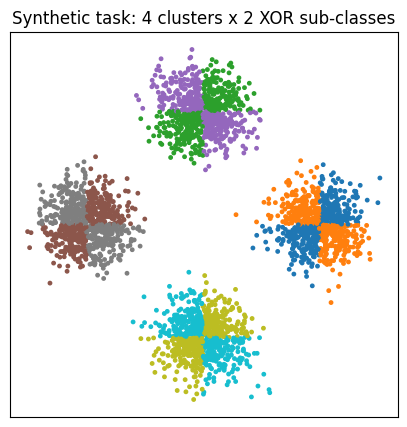

In [2]:
X, y = make_clusters(seed=0)
Xtr, ytr, Xte, yte = train_test_split(X, y, seed=0)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', s=6)
plt.title('Synthetic task: 4 clusters x 2 XOR sub-classes')
plt.xticks([]); plt.yticks([])
plt.show()

## 2. Train both gates

We train two identical models that differ only in the gate input: the channel-aware gate sees the channel quality `c`, the baseline does not. Both pay the same communication-cost penalty during training.

In [3]:
cfg = TrainConfig(steps=2000, beta=5.0, seed=0)

torch.manual_seed(0)
ca = ChannelAwareMoE(channel_aware=True)
train(ca, Xtr, ytr, cfg)

torch.manual_seed(0)
base = ChannelAwareMoE(channel_aware=False)
train(base, Xtr, ytr, cfg)
print('trained')

trained


## 3. Compare across channel conditions

The channel-aware gate adapts: high accuracy when the channel is good, graceful fallback (lower accuracy, near-zero cost) when it is poor. The baseline is flat — it cannot see the channel.

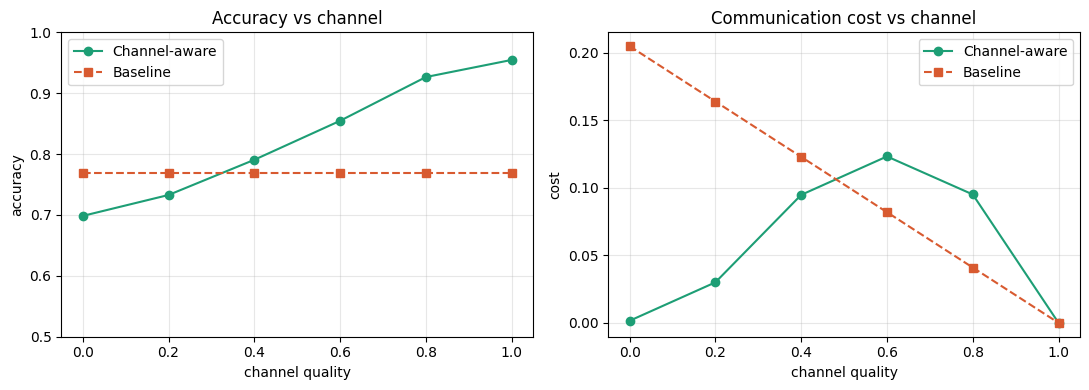

mean accuracy:  baseline 0.769  ->  channel-aware 0.826
mean cost:      baseline 0.102  ->  channel-aware 0.057


In [4]:
levels = torch.linspace(0, 1, 6)
rca = evaluate_by_channel(ca, Xte, yte, levels)
rb = evaluate_by_channel(base, Xte, yte, levels)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(rca['channel'], rca['accuracy'], 'o-', color='#1d9e75', label='Channel-aware')
ax[0].plot(rb['channel'], rb['accuracy'], 's--', color='#d85a30', label='Baseline')
ax[0].set_title('Accuracy vs channel'); ax[0].set_xlabel('channel quality')
ax[0].set_ylabel('accuracy'); ax[0].set_ylim(0.5, 1); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(rca['channel'], rca['comm_cost'], 'o-', color='#1d9e75', label='Channel-aware')
ax[1].plot(rb['channel'], rb['comm_cost'], 's--', color='#d85a30', label='Baseline')
ax[1].set_title('Communication cost vs channel'); ax[1].set_xlabel('channel quality')
ax[1].set_ylabel('cost'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"mean accuracy:  baseline {np.mean(rb['accuracy']):.3f}  ->  "
      f"channel-aware {np.mean(rca['accuracy']):.3f}")
print(f"mean cost:      baseline {np.mean(rb['comm_cost']):.3f}  ->  "
      f"channel-aware {np.mean(rca['comm_cost']):.3f}")

## 4. Probe the gate at any channel

Call `show_routing(c)` with any channel value in `[0, 1]` to see which route the gate picks across the input plane. Grey is the cheap local fallback; colours are remote specialists. Try `0.1`, `0.5`, `0.9`.

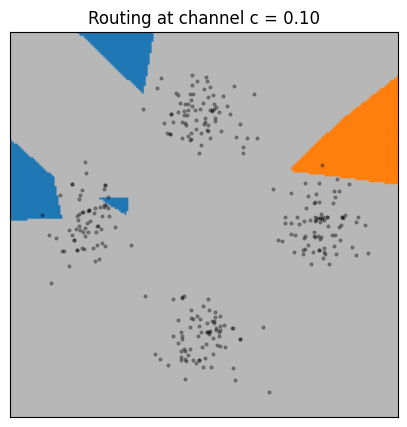

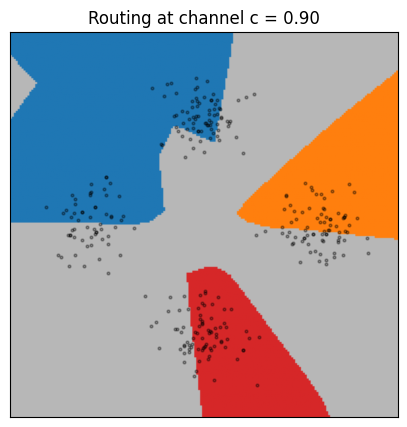

In [5]:
@torch.no_grad()
def show_routing(c, grid=200):
    xs = torch.linspace(float(X[:,0].min())-.5, float(X[:,0].max())+.5, grid)
    ys = torch.linspace(float(X[:,1].min())-.5, float(X[:,1].max())+.5, grid)
    gx, gy = torch.meshgrid(xs, ys, indexing='xy')
    pts = torch.stack([gx.reshape(-1), gy.reshape(-1)], 1)
    cb = torch.full((len(pts), 1), float(c))
    _, idx, _ = ca.hard_route(pts, cb)
    idx = idx.reshape(grid, grid).numpy()
    cmap = plt.get_cmap('tab10')
    rgb = np.zeros((*idx.shape, 3))
    for r in range(ca.n_routes):
        m = idx == r
        rgb[m] = (0.72,0.72,0.72) if r == ca.local_idx else cmap(r % 10)[:3]
    plt.figure(figsize=(5,5))
    plt.imshow(rgb, origin='lower', extent=(xs[0],xs[-1],ys[0],ys[-1]), aspect='auto')
    sub = X[torch.randint(0, len(X), (300,))].numpy()
    plt.scatter(sub[:,0], sub[:,1], s=4, c='black', alpha=.3)
    plt.title(f'Routing at channel c = {c:.2f}'); plt.xticks([]); plt.yticks([])
    plt.show()

show_routing(0.1)
show_routing(0.9)

## 5. Mobility: a time-varying channel

A device moving through varying coverage. The channel-aware gate tracks the channel almost perfectly; the baseline's routing is constant by construction (so its correlation with the channel is undefined / zero).

In [6]:
from camoe.mobility import run_mobility, coverage_profile

rows = run_mobility(ca, base, Xte, yte, n_steps=120, seed=0)
t = np.arange(len(rows['channel']))
fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax[0].fill_between(t, rows['channel'], color='#378add', alpha=.25)
ax[0].plot(t, rows['channel'], color='#185fa5'); ax[0].set_ylabel('channel'); ax[0].set_ylim(0,1)
ax[1].plot(t, rows['ca_acc'], color='#1d9e75', label='Channel-aware')
ax[1].plot(t, rows['base_acc'], color='#d85a30', ls='--', label='Baseline')
ax[1].set_ylabel('accuracy'); ax[1].set_xlabel('time step'); ax[1].legend(); ax[1].set_ylim(0.5,1)
plt.tight_layout(); plt.show()

corr = np.corrcoef(rows['channel'], rows['ca_remote'])[0, 1]
print(f'corr(channel, channel-aware remote routing) = {corr:.3f}')
print('baseline remote routing is constant -> correlation undefined (channel-blind)')

corr(channel, channel-aware remote routing) = 0.986
baseline remote routing is constant -> correlation undefined (channel-blind)


## Takeaway

Exposing the wireless channel state to a Mixture-of-Experts router lets it spend its communication budget intelligently: pay for remote specialists when the link is good, fall back locally when it is not. A channel-blind gate cannot do this. This is the toy version of a larger research direction on wireless-aware federated MoE for LLM agents.